In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/mutant_metrics.csv')

name_map = {
    "4.1 mini": "GPT 4.1-mini",
    "4.1": "GPT 4.1",
    "haiku": "Claude Haiku 3.5",
    "sonnet": "Claude Sonnet 4.0",
    "flash": "Gemini 2.5 Flash",
    "pro": "Gemini 2.5 Pro"
}


df = df.replace({"attacker": name_map, "defender": name_map})
df = df.rename(columns={"attacker": "Attacker", "defender": "Defender"})
df = df.fillna(0)
df['Score Attacker'] = df['score']
df['Score Defender'] = 1 - df['score']

df_scores = df[['Attacker', 'Score Attacker']].rename(columns={'Attacker': 'Model', 'Score Attacker': 'Score'})
df_scores = pd.concat([df_scores, df[['Defender', 'Score Defender']].rename(columns={'Defender': 'Model', 'Score Defender': 'Score'})], ignore_index=True)

df_aggregated = df.groupby(["Attacker", "Defender"]).mean(numeric_only=True).reset_index()
df_aggregated

,Attacker,Defender,score,mut_forfeit,mut_equivalent,mut_survived_turn,mut_survived_game,Score Attacker,Score Defender
0,claude-3-5-haiku-latest,claude-3-5-haiku-latest,0.125000,0.315000,0.366513,0.680711,0.286830,0.125000,0.875000
1,claude-3-5-haiku-latest,claude-sonnet-4-0,0.120000,0.315000,0.280280,0.649038,0.284361,0.120000,0.880000
2,claude-3-5-haiku-latest,gemini-2.5-flash,0.220000,0.490000,0.354363,0.283209,0.624483,0.220000,0.780000
3,claude-3-5-haiku-latest,gemini-2.5-pro,0.180000,0.470000,0.391015,0.228093,0.571907,0.180000,0.820000
4,claude-3-5-haiku-latest,gpt-4.1,0.210000,0.350000,0.353443,0.405421,0.562271,0.210000,0.790000
5,claude-3-5-haiku-latest,gpt-4.1-mini,0.225000,0.380000,0.485658,0.425974,0.509957,0.225000,0.775000
6,claude-sonnet-4-0,claude-3-5-haiku-latest,0.022222,0.800000,0.293122,0.611111,0.277778,0.022222,0.977778
7,claude-sonnet-4-0,claude-sonnet-4-0,0.022222,0.683333,0.249092,0.650030,0.127748,0.022222,0.977778
8,claude-sonnet-4-0,gemini-2.5-flash,0.222222,0.605556,0.296116,0.195286,0.702862,0.222222,0.777778
9,claude-sonnet-4-0,gemini-2.5-pro,0.255556,0.572222,0.241975,0.183333,0.716667,0.255556,0.744444


/tmp/ipykernel_1038/2905226594.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
/tmp/ipykernel_1038/2905226594.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
/tmp/ipykernel_1038/2905226594.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)


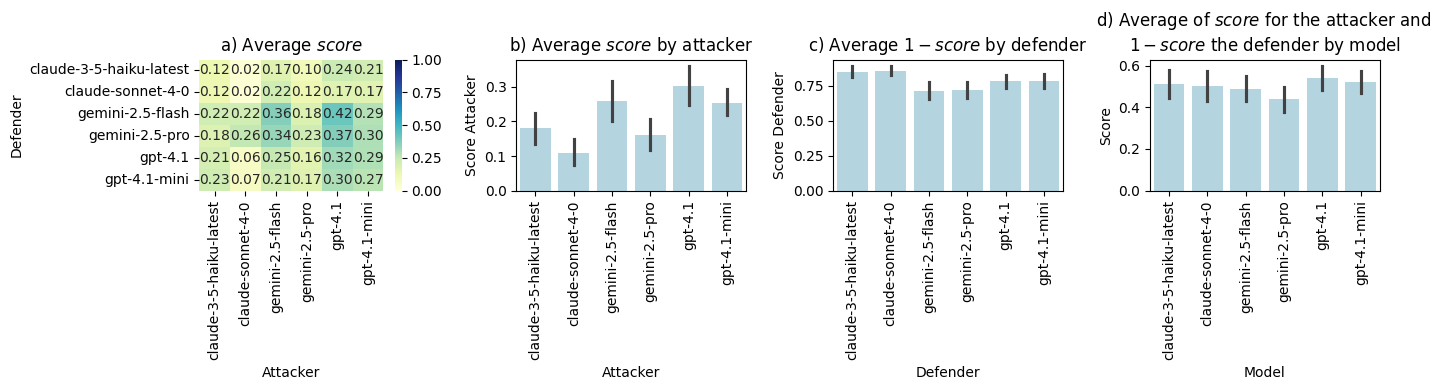

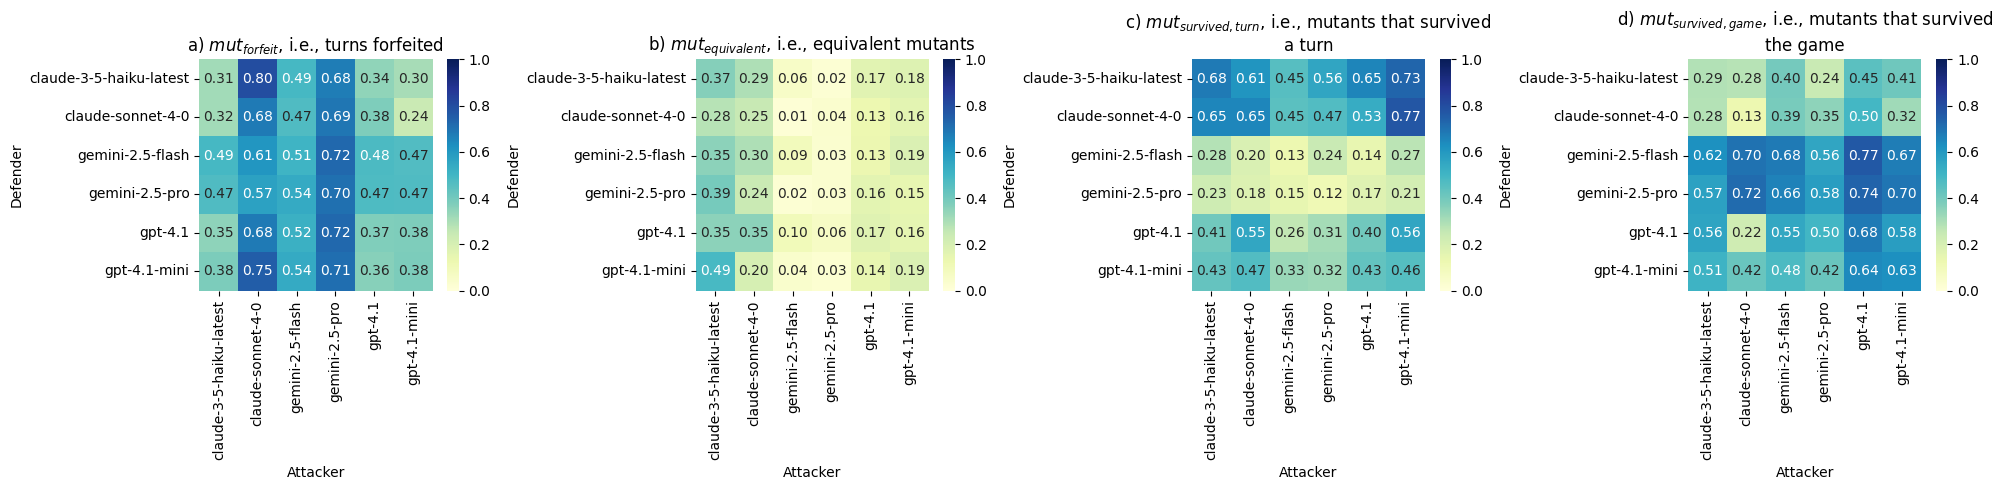

In [2]:
pivot_df_score = df_aggregated.pivot(columns="Attacker", index="Defender", values="score")
pivot_df_forfeit = df_aggregated.pivot(columns="Attacker", index="Defender", values="mut_forfeit")
pivot_df_equivalent = df_aggregated.pivot(columns="Attacker", index="Defender", values="mut_equivalent")
pivot_df_survived_turn = df_aggregated.pivot(columns="Attacker", index="Defender", values="mut_survived_turn")
pivot_df_survived_game = df_aggregated.pivot(columns="Attacker", index="Defender", values="mut_survived_game")

rot_x=90
rot_y=0
bar_color = "lightblue"
errorbar_type = "ci"
cbar_vmin = 0
cbar_vmax = 1

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

ax = axes[0]
sns.heatmap(pivot_df_score, annot=True, cmap="YlGnBu", fmt=".2f", ax=ax, vmin=cbar_vmin, vmax=cbar_vmax)
ax.set_title("a) Average $score$")
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
ax.set_yticklabels(ax.get_yticklabels(), rotation=rot_y)

ax = axes[1]
sns.barplot(data=df, x="Attacker", y="Score Attacker", ax=ax, color=bar_color, errorbar=errorbar_type)
ax.set_title("b) Average $score$ by attacker")
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)

ax = axes[2]
sns.barplot(data=df, x="Defender", y="Score Defender", ax=ax, color=bar_color, errorbar=errorbar_type)
ax.set_title("c) Average $1-score$ by defender")
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)

ax = axes[3]
sns.barplot(data=df_scores, x="Model", y="Score", ax=ax, color=bar_color, errorbar=errorbar_type)
ax.set_title("d) Average of $score$ for the attacker and \n$1-score$ the defender by model")
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)

plt.tight_layout()
plt.savefig("figures/scores.pdf", bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1,4, figsize=(20, 5))

ax = axes[0]
sns.heatmap(pivot_df_forfeit, annot=True, cmap="YlGnBu", ax=ax, fmt=".2f", vmin=cbar_vmin, vmax=cbar_vmax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
ax.set_yticklabels(ax.get_yticklabels(), rotation=rot_y)
ax.set_title("a) $mut_{forfeit}$, i.e., turns forfeited")

ax = axes[1]
sns.heatmap(pivot_df_equivalent, annot=True, cmap="YlGnBu", ax=ax, fmt=".2f", vmin=cbar_vmin, vmax=cbar_vmax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
ax.set_yticklabels(ax.get_yticklabels(), rotation=rot_y)
ax.set_title("b) $mut_{equivalent}$, i.e., equivalent mutants")

ax = axes[2]
sns.heatmap(pivot_df_survived_turn, annot=True, cmap="YlGnBu", ax=ax, fmt=".2f", vmin=cbar_vmin, vmax=cbar_vmax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
ax.set_yticklabels(ax.get_yticklabels(), rotation=rot_y)
ax.set_title("c) $mut_{survived,turn}$, i.e., mutants that survived\na turn")

ax = axes[3]
sns.heatmap(pivot_df_survived_game, annot=True, cmap="YlGnBu", ax=ax, fmt=".2f", vmin=cbar_vmin, vmax=cbar_vmax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=rot_x)
ax.set_yticklabels(ax.get_yticklabels(), rotation=rot_y)
ax.set_title("d) $mut_{survived,game}$, i.e., mutants that survived\nthe game")

plt.tight_layout()
plt.savefig("figures/mutations.pdf", bbox_inches='tight')
plt.show()

In [3]:
metrics_map = {
    "score": "$score$",
    "mut_forfeit": "$mut_{forfeit}$",
    "mut_equivalent": "$mut_{equivalent}$",
    "mut_survived_turn": "$mut_{survived,turn}$",
    "mut_survived_game": "$mut_{survived,game}$"
}

df_aggregated = df_aggregated.rename(columns=metrics_map)
df_aggregated.drop(columns=["Score Attacker", "Score Defender"], inplace=True)

results_tex = df_aggregated.to_latex(index=False, float_format="%.2f")
print(results_tex)

\begin{tabular}{llrrrrr}
\toprule
Attacker & Defender & $score$ & $mut_{forfeit}$ & $mut_{equivalent}$ & $mut_{survived,turn}$ & $mut_{survived,game}$ \\
\midrule
claude-3-5-haiku-latest & claude-3-5-haiku-latest & 0.12 & 0.31 & 0.37 & 0.68 & 0.29 \\
claude-3-5-haiku-latest & claude-sonnet-4-0 & 0.12 & 0.32 & 0.28 & 0.65 & 0.28 \\
claude-3-5-haiku-latest & gemini-2.5-flash & 0.22 & 0.49 & 0.35 & 0.28 & 0.62 \\
claude-3-5-haiku-latest & gemini-2.5-pro & 0.18 & 0.47 & 0.39 & 0.23 & 0.57 \\
claude-3-5-haiku-latest & gpt-4.1 & 0.21 & 0.35 & 0.35 & 0.41 & 0.56 \\
claude-3-5-haiku-latest & gpt-4.1-mini & 0.23 & 0.38 & 0.49 & 0.43 & 0.51 \\
claude-sonnet-4-0 & claude-3-5-haiku-latest & 0.02 & 0.80 & 0.29 & 0.61 & 0.28 \\
claude-sonnet-4-0 & claude-sonnet-4-0 & 0.02 & 0.68 & 0.25 & 0.65 & 0.13 \\
claude-sonnet-4-0 & gemini-2.5-flash & 0.22 & 0.61 & 0.30 & 0.20 & 0.70 \\
claude-sonnet-4-0 & gemini-2.5-pro & 0.26 & 0.57 & 0.24 & 0.18 & 0.72 \\
claude-sonnet-4-0 & gpt-4.1 & 0.06 & 0.68 & 0.35 & 0